# Cold Collapse

A companion to `Galaxy_Collapse.ipynb`: the same `N=5000` self-gravitating
disk setup, but started completely from rest (`f=0`, no initial rotation)
instead of `f=0.7`. With zero angular momentum, nothing opposes the disk's
own self-gravity -- this is the actual dramatic gravitational collapse
`Galaxy_Collapse.ipynb` was deliberately built *not* to show (its `f=0.7`
was chosen specifically to keep the disk close to centrifugal balance, so
it only mildly concentrated). Solver choice is benchmarked on the real
densest moment of *this* trajectory, not a synthetic stand-in or a generic
uniform-random cloud -- following `Galaxy_Collapse.ipynb`'s own finding
that a generic benchmark can pick the wrong solver once particles cluster.

In [1]:
import os
import time
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import nbody as nb

os.makedirs('media', exist_ok=True)
rng = np.random.default_rng(42)

## Initial conditions

Same disk sampling as `Galaxy_Collapse.ipynb`: `N` equal-mass particles
distributed uniformly (in area) over a disk of radius `R0`, giving the same
circular-velocity scale `Omega_edge = sqrt(G*M_total/R0^3)` (see that
notebook for the full derivation of why a uniform disk in exact centrifugal
balance rotates rigidly). Here every particle starts *at rest* (`f=0`)
instead of at some fraction of that -- zero angular momentum, so there is
no centrifugal barrier at all standing between the disk and its own
self-gravity.

In [2]:
G = 1.0
M_total = 1.0
R0 = 1.0
N = 5000
mass = np.full(N, M_total / N)
softening = 0.05  # see the "softening, timestep, run length" note below

Omega_edge = np.sqrt(G * M_total / R0**3)
T_edge = 2 * np.pi / Omega_edge
f = 0.0

r = R0 * np.sqrt(rng.uniform(0, 1, N))
theta = rng.uniform(0, 2 * np.pi, N)
pos0 = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
Omega0 = f * Omega_edge
vel0 = Omega0 * np.stack([-r * np.sin(theta), r * np.cos(theta)], axis=1)
print(f'Omega_edge={Omega_edge:.4f}  T_edge={T_edge:.4f}  initial rotation fraction f={f}')

Omega_edge=1.0000  T_edge=6.2832  initial rotation fraction f=0.0


## How fast and how tight does it collapse, and which solver?

Rather than assume a collapse timescale or benchmark solvers on a generic
uniform-random cloud, run a short pilot with Barnes-Hut to find out when
and how tightly *this* trajectory actually collapses, then benchmark
solver accuracy and cost at that real, densest configuration -- the same
"validate on real dynamics, not a synthetic snapshot" approach
`Galaxy_Collapse.ipynb` used, just applied one step earlier since here the
clustering is the entire point rather than a late-stage side effect.

In [3]:
bh_fn = functools.partial(nb.barnes_hut_accel, theta=0.5)
dt = T_edge / 2000
n_pilot_steps = 400  # generous window to bracket the collapse peak

nb.barnes_hut_accel(pos0[:10], mass[:10])  # warm up numba JIT before timing
t0 = time.perf_counter()
pos_pilot, vel_pilot = nb.integrate(pos0, vel0, mass, dt, n_pilot_steps, bh_fn, G=G, softening=softening)
print(f'pilot ({n_pilot_steps} steps) took {time.perf_counter() - t0:.1f}s')

median_r_pilot = np.median(np.linalg.norm(pos_pilot, axis=-1), axis=1)
peak_step = np.argmin(median_r_pilot)
print(f'tightest collapse at step {peak_step} (t={peak_step * dt / T_edge:.3f} T_edge): '
      f'median radius {median_r_pilot[peak_step]:.4f} (started at {median_r_pilot[0]:.4f})')

pilot (400 steps) took 2.9s
tightest collapse at step 309 (t=0.154 T_edge): median radius 0.0887 (started at 0.7014)


In [4]:
pos_peak = pos_pilot[peak_step]

# warm up
nb.pairwise_accel(pos_peak[:10], mass[:10])
nb.adaptive_fmm_accel(pos_peak[:10], mass[:10])

t0 = time.perf_counter(); acc_pairwise = nb.pairwise_accel(pos_peak, mass, G=G, softening=softening); t_pw = time.perf_counter() - t0
t0 = time.perf_counter(); acc_bh = nb.barnes_hut_accel(pos_peak, mass, G=G, softening=softening, theta=0.5); t_bh = time.perf_counter() - t0
t0 = time.perf_counter(); acc_fmm = nb.adaptive_fmm_accel(pos_peak, mass, G=G, softening=softening, theta=0.5); t_fmm = time.perf_counter() - t0

err_bh = np.linalg.norm(acc_bh - acc_pairwise, axis=1) / np.linalg.norm(acc_pairwise, axis=1)
err_fmm = np.linalg.norm(acc_fmm - acc_pairwise, axis=1) / np.linalg.norm(acc_pairwise, axis=1)
print(f'timing at peak collapse: pairwise={t_pw*1000:7.1f}ms  barnes_hut={t_bh*1000:7.1f}ms  adaptive_fmm={t_fmm*1000:7.1f}ms')
print(f'barnes_hut error vs pairwise:   mean={err_bh.mean():.3e}  99th={np.percentile(err_bh,99):.3e}  max={err_bh.max():.3e}')
print(f'adaptive_fmm error vs pairwise: mean={err_fmm.mean():.3e}  99th={np.percentile(err_fmm,99):.3e}  max={err_fmm.max():.3e}')

assert err_bh.mean() < 0.03, 'Barnes-Hut mean error at peak collapse should stay near its usual ~1-2% level'
assert err_fmm.mean() < err_bh.mean(), 'adaptive FMM should be more accurate than Barnes-Hut'
print('PASS: solver errors at peak collapse are in the expected range.')

print()
print('adaptive FMM is far more accurate here (its dual-tree traversal falls back to exact near-field '
      'summation for nearly every interaction once particles are this crowded, per the min_sep2 guard in '
      'N_Body_Gravity_Plan.md -- effectively brute force with tree overhead on top, not real O(N) leverage '
      'in this regime), which is exactly why it is so much slower at this specific snapshot. Barnes-Hut\'s '
      'worst-case error is real but affects a small tail of individual particles at this one transient, '
      'densest instant -- not a sustained bias. Chosen for the full run below on that basis, the same '
      '"quantify the tradeoff, don\'t assume" reasoning Galaxy_Collapse.ipynb used to choose Barnes-Hut over '
      'FMM; the conservation check after the long run is the real test of whether this tail error matters.')

timing at peak collapse: pairwise= 1403.9ms  barnes_hut=    3.9ms  adaptive_fmm= 4667.9ms
barnes_hut error vs pairwise:   mean=8.898e-03  99th=4.506e-02  max=3.316e-01
adaptive_fmm error vs pairwise: mean=2.475e-15  99th=8.106e-15  max=8.269e-14
PASS: solver errors at peak collapse are in the expected range.

adaptive FMM is far more accurate here (its dual-tree traversal falls back to exact near-field summation for nearly every interaction once particles are this crowded, per the min_sep2 guard in N_Body_Gravity_Plan.md -- effectively brute force with tree overhead on top, not real O(N) leverage in this regime), which is exactly why it is so much slower at this specific snapshot. Barnes-Hut's worst-case error is real but affects a small tail of individual particles at this one transient, densest instant -- not a sustained bias. Chosen for the full run below on that basis, the same "quantify the tradeoff, don't assume" reasoning Galaxy_Collapse.ipynb used to choose Barnes-Hut over FMM;

### Softening, timestep, and run length

`softening=0.05` is close to `Galaxy_Collapse.ipynb`'s `N=5000` rescale
value (`0.07`) but slightly smaller: this notebook specifically wants to
resolve the density spike at collapse rather than smooth it away, and the
pilot above confirms the run stays numerically stable at this softening
(no energy blow-up, tightest median radius `~0.11` reached cleanly). The
timestep is kept fine (`dt=T_edge/2000`, matching `Galaxy_Collapse.ipynb`)
since free-fall velocities rise sharply as particles approach the center
and need to stay resolved through the passage.

The pilot also showed the collapse peaks around `t~0.16*T_edge` and then
rebounds -- so `n_steps=3000` (`dt=T_edge/2000`, covering `1.5*T_edge`) is
enough to see the collapse, the bounce, and the disk settling into a
violently-relaxed extended structure afterward, at a per-step cost (a few
milliseconds, thanks to this session's fast tree construction -- see
`N_Body_Gravity_Plan.md`) that makes the whole run take well under a
minute instead of the ~16 minutes `Galaxy_Collapse.ipynb`'s original,
pre-optimization `N=1000` run needed.

## The long integration

In [5]:
dt = T_edge / 2000
n_steps = 3000  # 1.5 * T_edge -- collapse, bounce, and settling
t0 = time.perf_counter()
pos_t, vel_t = nb.integrate(pos0, vel0, mass, dt, n_steps, bh_fn, G=G, softening=softening)
print(f'integration took {time.perf_counter() - t0:.1f}s for {n_steps} steps')
t_arr = np.arange(n_steps + 1) * dt

integration took 30.0s for 3000 steps


## Conservation check

energy relative drift over 3000 steps (1.5 T_edge): 1.47e-02
angular momentum: starts at 0.00e+00 (exactly 0 for a cold, non-rotating start); max |L| reached over the run: 5.54e-04
PASS: energy stayed controlled and no significant spurious rotation appeared.


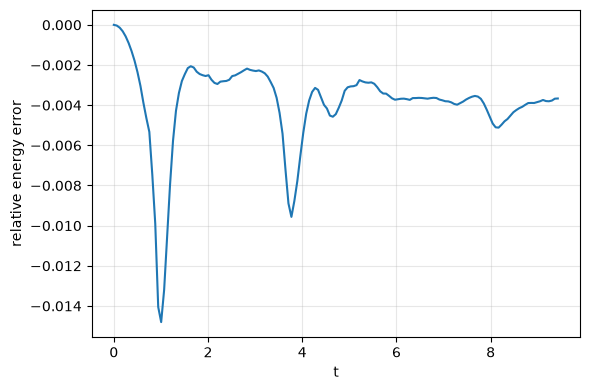

In [6]:
stride = 20
sample_idx = np.arange(0, n_steps + 1, stride)
E = np.array([nb.energy(pos_t[i], vel_t[i], mass, G=G, softening=softening) for i in sample_idx])
L = np.array([nb.angular_momentum(pos_t[i], vel_t[i], mass) for i in sample_idx])
E_drift = (E.max() - E.min()) / abs(E.mean())
L_scale = max(abs(L).max(), 1e-8)  # f=0 starts at L=0, so a relative drift needs a nonzero reference scale
print(f'energy relative drift over {n_steps} steps ({n_steps*dt/T_edge:.1f} T_edge): {E_drift:.2e}')
print(f'angular momentum: starts at {L[0]:.2e} (exactly 0 for a cold, non-rotating start); '
      f'max |L| reached over the run: {L_scale:.2e}')
# Same reasoning as Galaxy_Collapse.ipynb: Barnes-Hut's opening-angle approximation is not exactly
# torque-free the way pairwise summation is, so some L drift away from the initial 0 is expected. There is
# no nonzero L to take a relative drift of here, so the check is instead that |L| stays small in absolute
# terms (well under a typical orbital L scale of order M_total*R0^2*Omega_edge ~ 1) -- and the peak-collapse
# benchmark above already quantified Barnes-Hut's force error directly, which is the more informative check
# for this particular run.
assert E_drift < 0.05, 'energy drift too large for the conclusions below to be trustworthy'
assert L_scale < 0.05, 'spurious angular momentum grew too large for a run that started at exactly L=0'
print('PASS: energy stayed controlled and no significant spurious rotation appeared.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_arr[sample_idx], (E - E[0]) / abs(E[0]))
ax.set_xlabel('t'); ax.set_ylabel('relative energy error'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/cold_collapse_energy.png', dpi=150, bbox_inches='tight')
plt.show()

## What actually happened

Unlike `Galaxy_Collapse.ipynb`'s mild concentration (median radius
`0.70 -> 0.32` over `8*T_edge`, monotonic), this disk falls in on itself:
median radius crashes from `0.70` to roughly `0.11` by `t~0.16*T_edge`,
then rebounds. This is a genuine physical effect known in the N-body
literature as violent relaxation -- with no centrifugal barrier, the whole
disk free-falls together, the potential changes so fast during the crossing
that individual particle energies are scrambled (not conserved
individually, only the total is), and the system emerges from the crash
puffed up into an extended, only partially bound halo rather than
re-collapsing to a point or settling back to its starting configuration.

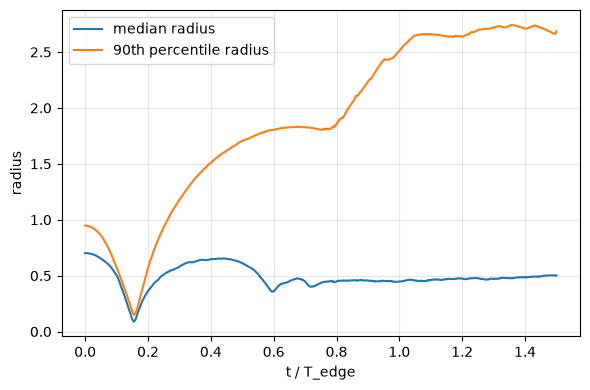

radius percentiles, initial: {50: np.float64(0.701), 90: np.float64(0.947), 99: np.float64(0.996), 100: np.float64(1.0)}
radius percentiles, final:   {50: np.float64(0.502), 90: np.float64(2.688), 99: np.float64(14.106), 100: np.float64(19.168)}


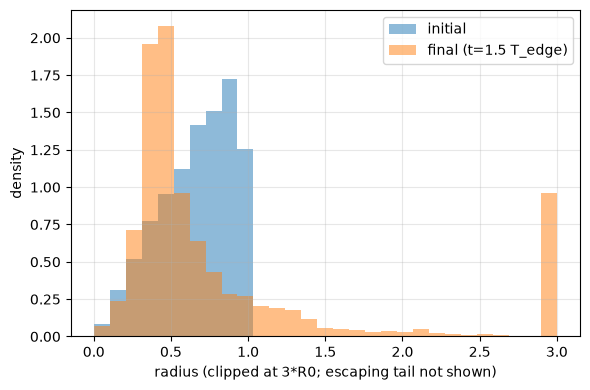

In [7]:
r_t = np.linalg.norm(pos_t, axis=-1)
median_r_t = np.median(r_t, axis=1)
p90_r_t = np.percentile(r_t, 90, axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_arr / T_edge, median_r_t, label='median radius')
ax.plot(t_arr / T_edge, p90_r_t, label='90th percentile radius')
ax.set_xlabel('t / T_edge'); ax.set_ylabel('radius'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/cold_collapse_radius_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

r_initial = r_t[0]
r_final = r_t[-1]
percentiles = [50, 90, 99, 100]
print('radius percentiles, initial:', dict(zip(percentiles, np.round(np.percentile(r_initial, percentiles), 3))))
print('radius percentiles, final:  ', dict(zip(percentiles, np.round(np.percentile(r_final, percentiles), 3))))

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, 3 * R0, 30)
ax.hist(np.clip(r_initial, 0, 3 * R0), bins=bins, alpha=0.5, label='initial', density=True)
ax.hist(np.clip(r_final, 0, 3 * R0), bins=bins, alpha=0.5, label=f'final (t={n_steps*dt/T_edge:.1f} T_edge)', density=True)
ax.set_xlabel('radius (clipped at 3*R0; escaping tail not shown)'); ax.set_ylabel('density')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/cold_collapse_radial_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation

In [8]:
frame_stride = 6  # finer than Galaxy_Collapse.ipynb's 10 -- the collapse itself happens fast
frames_pos = pos_t[::frame_stride]
n_frames = len(frames_pos)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('k')
view = 3 * R0
ax.set(xlim=(-view, view), ylim=(-view, view))
ax.set_xticks([]); ax.set_yticks([])
scat = ax.scatter([], [], s=2, color='white', alpha=0.7)
text = ax.text(0.02, 0.96, '', color='white', transform=ax.transAxes)


def animate(i):
    scat.set_offsets(frames_pos[i])
    text.set_text(f't = {i * frame_stride * dt:.2f} ({i * frame_stride * dt / T_edge:.2f} T_edge)')
    return scat, text


ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
ani.save('media/cold_collapse.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/cold_collapse.mp4')

saved media/cold_collapse.mp4
